# Exploratory Data Analysis (EDA)

In this notebook, we automatically download and explore the Credit Card Fraud Detection dataset from Kaggle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import shutil
import os

warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Load Data

In [2]:
# Download latest version
print("Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to downloaded dataset files:", path)

# Find the CSV and copy it to data/raw
csv_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)
            break

dest = '../data/raw/creditcard.csv'
os.makedirs('../data/raw', exist_ok=True)
if csv_path:
    shutil.copy(csv_path, dest)
    print(f"Dataset successfully copied to {dest}")

# Load the dataset
df = pd.read_csv(dest)
df.head()

Path to downloaded dataset files: /home/jules/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


Dataset successfully copied to ../data/raw/creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Basic Information

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Number of rows: 284807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values: 0


Duplicate rows: 1081


## 3. Target Variable Analysis

In [4]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {(class_counts[1] / len(df)) * 100:.3f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


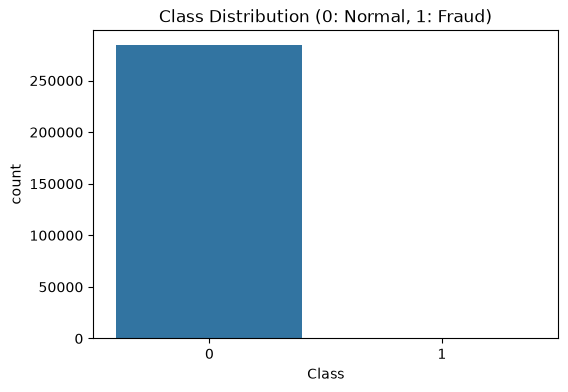

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.show()

## 4. Transaction Amount Distribution

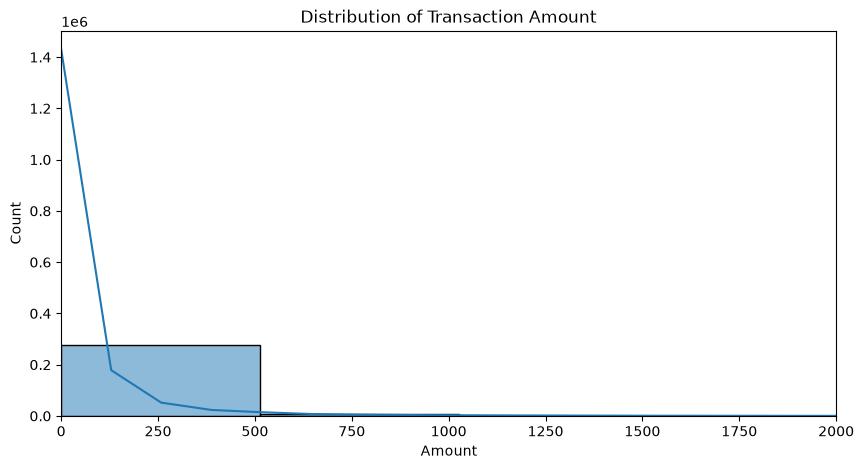

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlim(0, 2000)
plt.show()

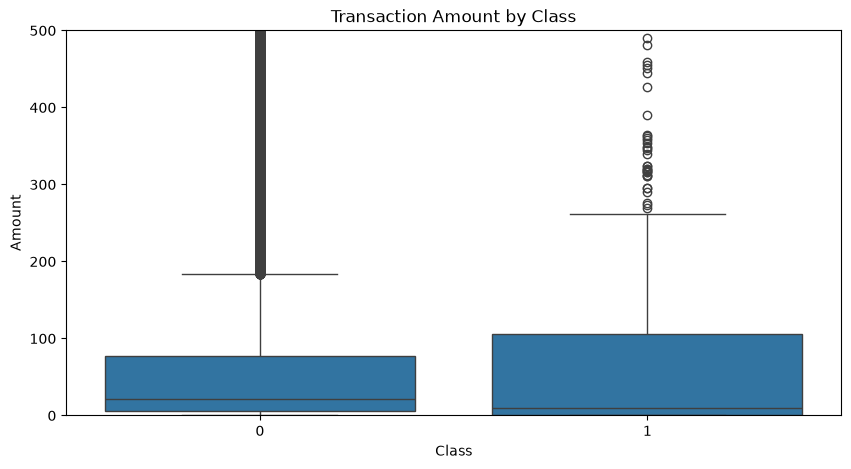

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.ylim(0, 500)
plt.show()

## 5. Correlation Heatmap
Since most features (V1-V28) are PCA components, they should be uncorrelated. Let's verify this and see how they correlate with 'Class'.

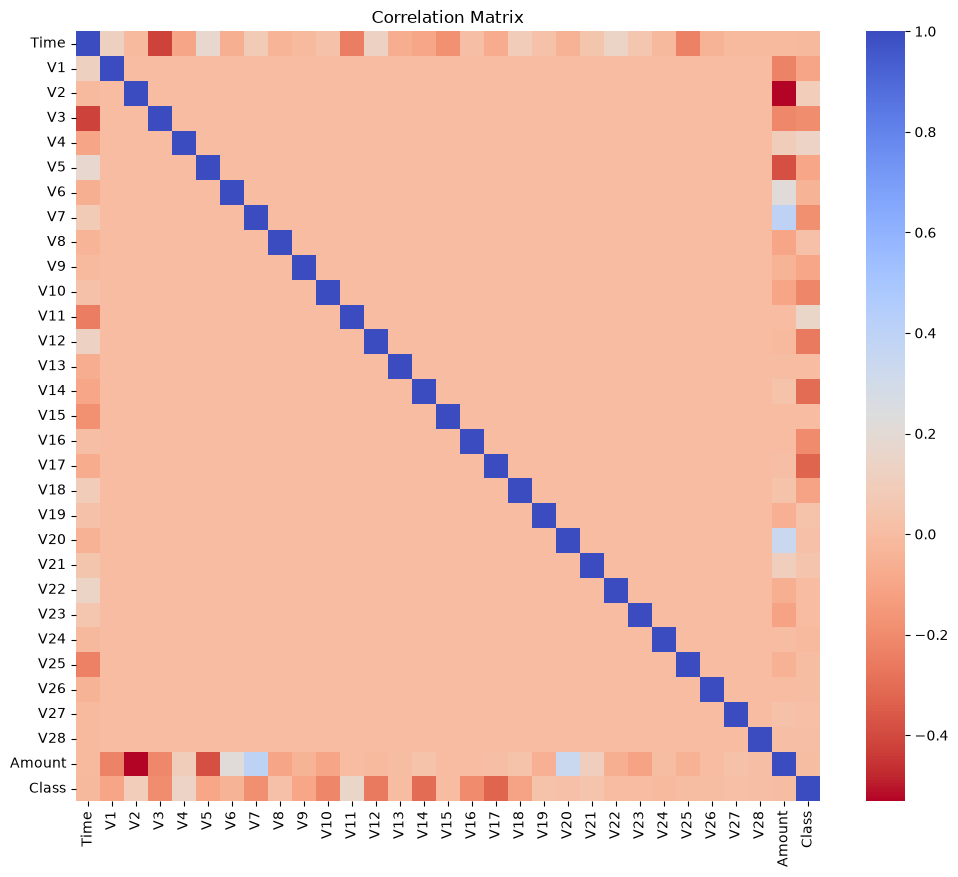

In [8]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('Correlation Matrix')
plt.show()

## 6. Concise EDA Report

- **Target Column:** The target column is `Class` (0 for normal, 1 for fraudulent).
- **Class Imbalance:** The dataset is **highly imbalanced**. Out of 284,807 transactions, only 492 are fraudulent (0.173%). This means standard metrics like accuracy will be misleading, and techniques like resampling (e.g., SMOTE) or class weighting will be necessary for modeling.
- **Features:** There are 30 features. Features `V1` to `V28` are anonymized numerical features resulting from a PCA transformation. The original features and more background information are not provided due to confidentiality. `Time` and `Amount` are the only non-transformed features.
- **Missing Values:** There are absolutely 0 missing values in the dataset.
- **Data Scaling:** The `Amount` and `Time` features are on vastly different scales compared to the PCA features (`V1`-`V28`), meaning standard scaling will be required before training linear models or neural networks.